# *ADS EXP 6* - IMPLEMENTING TIME SERIES FORECASTING

In [184]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels import tsa

In [185]:
df = pd.read_csv("supermarket_sales - Sheet1.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [186]:
df['Date'] = pd.to_datetime(df['Date'])
df.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6


In [187]:
# filter by city, remove unnecessary columns, then preview the result.
data = df.loc[df['City'] == 'Yangon']
r_col = ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating',]


data.drop(r_col, axis =1 , inplace=True)
data.head()

C:\Users\Anshul Parkar\AppData\Local\Temp\ipykernel_45448\1338952429.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(r_col, axis =1 , inplace=True)


,Total,Date
0,548.9715,2019-01-05
2,340.5255,2019-03-03
3,489.0480,2019-01-27
4,634.3785,2019-02-08
6,433.6920,2019-02-25


In [188]:
data = data[["Date","Total"]]
data = data.sort_values('Date')
data.set_index('Date', inplace=True)
print(data.head())
df1=data

              Total
Date               
2019-01-01  113.568
2019-01-01  399.756
2019-01-01  621.243
2019-01-01  457.443
2019-01-01  779.310


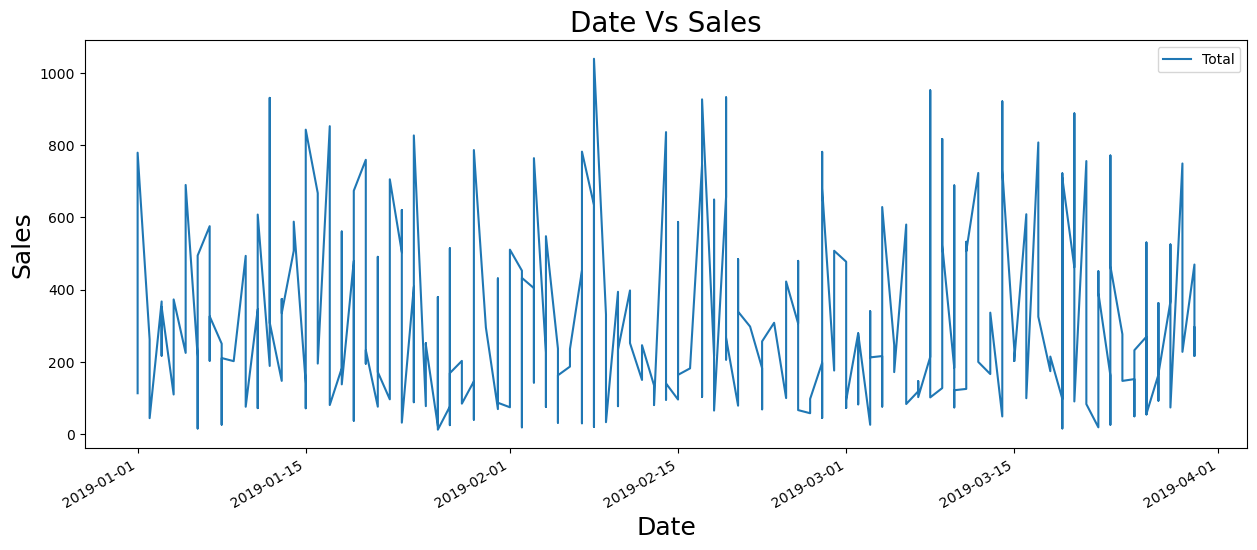

In [189]:
data.plot(figsize=(15,6),legend=True)
plt.ylabel("Sales",fontsize=18)
plt.xlabel("Date",fontsize=18)
plt.title("Date Vs Sales",fontsize=20)
plt.show()

#### Below code runs the Augmented Dickey-Fuller (ADF) test to check whether your time series is stationary.

- Why this is used:

1. ARIMA-type models usually work best when the series is stationary (mean/variance do not drift over time).
2. ADF helps decide if you need differencing before modeling.
3. It gives statistical evidence, not just visual guesswork from plots.

- What your outputs mean:

1. ADF Statistic: test statistic (more negative generally supports stationarity).
2. p-value: key decision value.
3. Null hypothesis (H0): series has a unit root, meaning non-stationary.
4. If p-value < 0.05: reject H0, treat series as stationary.
5. If p-value >= 0.05: fail to reject H0, likely non-stationary, apply differencing and test again.

''' Arima stands for AutoRegressive Integrated Moving Average. It’s a powerful model for forecasting time series data, especially when the data shows trends or seasonality. The "Integrated" part refers to differencing the data to make it stationary, which is often necessary for accurate forecasting. '''

In [190]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['Total'])
print('ADF Statistic: ', result[0])
print('p-value: ', result[1])


ADF Statistic:  -18.713510280720456
p-value:  2.0341957129649963e-30


In [191]:
# Resampling creates a clean daily sequence for decomposition, ACF/PACF, and ARIMA.
data = data['Total'].resample('D').mean()
# data_diff = data.diff().dropna()
print(data.head())

Date
2019-01-01    474.26400
2019-01-02    153.52575
2019-01-03    312.46950
2019-01-04    241.63125
2019-01-05    404.90100
Freq: D, Name: Total, dtype: float64


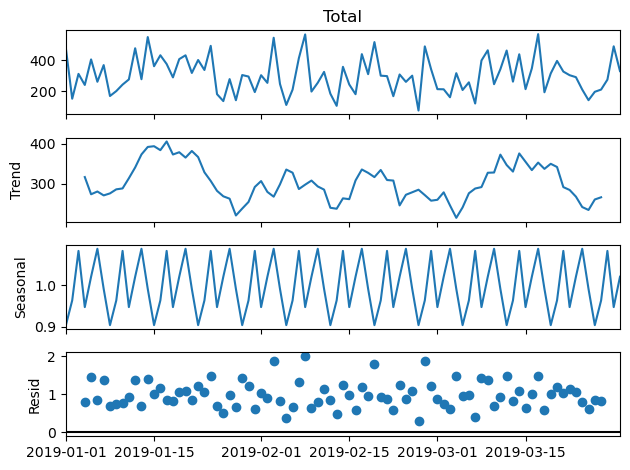

In [192]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_result_mult = seasonal_decompose(data, model="multiplicative")

trend = decompose_result_mult.trend
seasonal = decompose_result_mult.seasonal
residual = decompose_result_mult.resid

decompose_result_mult.plot();

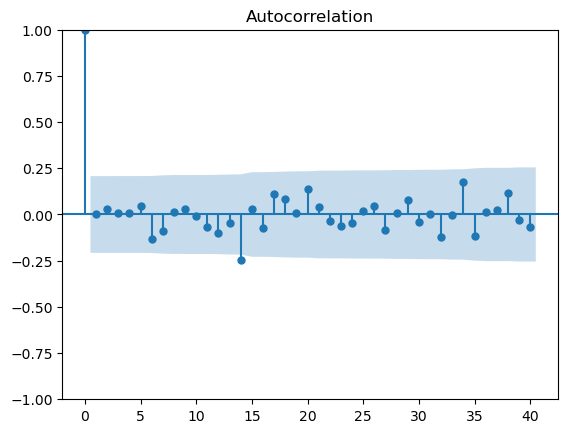

In [193]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig = sm.graphics.tsa.plot_acf(data, lags=40)

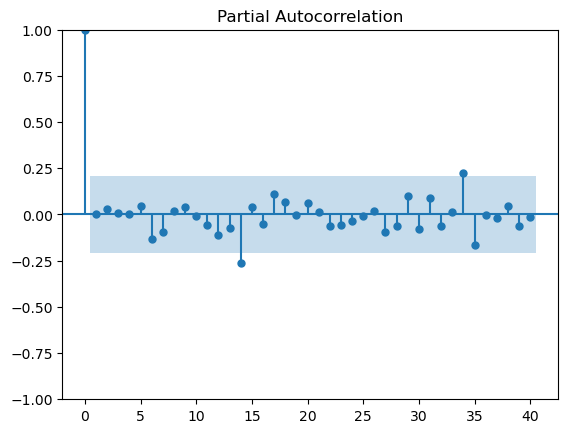

In [194]:
fig = sm.graphics.tsa.plot_pacf(data, lags=40)

#### NOTE: these plots help you understand time dependence and pick reasonable ARIMA order values instead of guessing blindly

In [195]:
from sklearn.model_selection import train_test_split
inputs = df1.index # df 1 created earlier in 4th cell
target = df1['Total'].copy()
X_train, X_test, y_train, y_test = train_test_split(inputs,target, test_size=1/3, random_state=0)


In [196]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from math import sqrt
# ARIMA(p, d, q):
#   p = 0 → no autoregressive part
#   d = 3 → difference three times (integration part)
#   q = 1 → one moving average term
model = ARIMA(y_train, order=(0,3,1))
model_fit = model.fit()


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-

In [197]:
predictions = model_fit.forecast(len(y_test))


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [198]:
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)*100
rmse = sqrt(mse)
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")


MSE: 1279666154.57
MAE: 30326.32
MAPE: 22000.16%
RMSE: 35772.42
